In [1]:
#Imports
# It is necessary to install the scipy package to precompile some of the functions with @njit.
import numpy as np
import math as math
import sympy as sp
import matplotlib.pyplot as plt
import itertools as it
from itertools import combinations
import numba as numba
from numba import njit

## Auxiliary Functions

In [2]:
#Distancias y vectores
#---------------------

#Computes the euclidean disance between two points.
@njit
def distancia_vectores(v1,v2):
    return(np.linalg.norm(v1-v2))


#Given a point v, computes the absolute difference between each pair of elements in different positions of the vector.
#Then, it is checked whether the minimum of these differences is less than epsilon. If so, True is returned. Otherwise, False.
@njit
def cond_norma_min(v,epsilon):
    n=len(v)
    
    for i in range (n):
        for j in range (i+1,n):
            d=abs(v[i]-v[j])
            if d<epsilon:
                return(True)
    return False

#Given a point v, computes the difference between each pair of distinct elements of the vector in absolute value and the minimum
# of these differences is returned.
@njit
def norma_min(v):
    n=len(v)
    dis=1e60
    for i in range (n):
        for j in range (i+1,n):
            d=np.abs(v[i]-v[j])

    if d<dis:
        dis=d
    return(dis)
v=np.array([1,2,3],np.complex128)

#Given a vector z1 in the complex plane, this function returns a vector perpendicular to z1.@njit
def perpendicular(z1):
    return(1j*z1)


def vec_perp(v,coord):
    return np.array([perpendicular(v[coord]) for vi in v])

In [3]:
#Symmetrical polynomials and Vieta map
#-----------------------------------------------

#This function receives a point x and returns a list with the value of the symmetric polynomials from e_0 to e_len(x) evaluated at the point x.
@njit
def pol_simetricos(x):
    l=len(x)
    e=np.zeros(l+1,dtype=np.complex128)
    e[0]=1
    for xi in x:
        for i in range(l,0,-1):
            e[i]+=xi*e[i-1]
    return(e)

v = np.array([1j+5, 3, 4j])
s1=pol_simetricos(v)
#print(s1)


#This function returns the value of the Vieta map (of order len(x)) evaluated at the point x. 
@njit
def Vieta(x):
    e=pol_simetricos(x)
    l=len(x)
    coef=(np.zeros(l,dtype=np.complex128))
    for i in range(1,l+1):
        coef[i-1]=(-1)**i*e[i]
    return(coef)

#print(Vieta(v))

##This function computes  the value of the Jacobian matrix of the Vieta map (of order len(x)) evaluated at the point x.
@njit
def Jacobiana(x):
    l=len(x)
    J=np.zeros((l,l),dtype=np.complex128)
    for i in range(l):
        aux=np.concatenate((x[:i],x[i+1:]))
        e=pol_simetricos(aux)
        for j in range(l):
            J[j,i]=(-1)**(j+1)*e[j]
    return(J)


#Error made in the evaluation of a polynomial associated to p_final on the set of roots lp_final.
def errorM(lp_final,p_final):
    coef=np.insert(p_final,0,1)
    ev=np.polyval(coef,lp_final)
    er=np.abs(ev)
    return(np.max(er))

#Jacobiana(v)

In [4]:
# Auxilary functions for the second algorithm (Discriminante):
#-------------------------------------------------------------

#This function takes a point and computes a list with the coefficients of the derivative of the polynomial associated with the tuple in the codomain of the Vieta map:
@njit
def coef_derivada(punto):
    n=len(punto)
    puntoc=np.array([1]+list(punto), dtype=np.complex128)
    exponentes=np.arange(n,-1,-1)
    coef_der=puntoc*exponentes
    return(coef_der[:-1])


punto=np.array([1+1j,2,3])
coef_derivada(punto)

#This function receives a point and computes the absolute value of the discriminant of the polynomial associated with the point in the codomain of the Vieta map.
@njit 
def resultante(punto):
    n=len(punto)
    dim=2*n-1
    derivada=coef_derivada(punto)
    puntoc=np.array([1]+list(punto), dtype=np.complex128)
    

    syl=np.zeros((dim,dim), dtype=np.complex128)
    for i in range(n-1):
        syl[i,i:i+n+1]=puntoc
    for i in range (n):
        syl[i+n-1,i:i+n]=derivada

    determinate=np.abs(np.linalg.det(syl))
    return(determinate)
resultante(punto)

# Normalized discriminant
@njit 
def resultanteR(punto):
    n=len(punto)
    dim=2*n-1
    derivada=coef_derivada(punto)
    puntoc=np.array([1]+list(punto), dtype=np.complex128)
    
    syl=np.zeros((dim,dim), dtype=np.complex128)
    for i in range(n-1):
        syl[i,i:i+n+1]=puntoc
    for i in range (n):
        syl[i+n-1,i:i+n]=derivada

    determinate=np.abs(np.linalg.det(syl))**(1/dim)
    return(determinate)

#resultanteNorm(punto)

In [5]:
# Auxiliary functions for Alg_3
#-----------------------------------------
# This function takes a point (p_actual) in the domain of the Vieta map and a point (p_final) in the codomain associated with the polynomial whose roots are being sought.
# The function computes the normalized vector obtained by multiplying the inverse of the Jacobian matrix at p_actual by the vector (p_final - Vieta(p_actual)).
# (Tangent vector)


@njit
def dir_sig_punto(p_actual,p_final):
    jp_actual=Jacobiana(p_actual)
    im_punto_inicial=Vieta(p_actual)
    
    norma=np.linalg.norm(p_final-im_punto_inicial)
    if norma< 1e-24:
        return(np.zeros(len(p_actual), dtype=np.complex128))
    else:
        direc=(p_final-im_punto_inicial)/norma
        direcL=np.linalg.solve(jp_actual, direc)
        direcLN=direcL/np.linalg.norm(direcL)
        
        return(direcLN)

#p_actual=np.array([5,6,7j,1+1j,7], dtype=np.complex128)
#p_final=np.array([5,6,7+1j,5,71], dtype=np.complex128)
#dir_sig_punto(p_actual,p_final)

In [6]:
# Functions to compute path liftings.
#------------------------------------------

# Given a (non-critical) point x0 in the domain of the Vieta map, its image (Vieta(x0)), and another point fx1 (ordinary) in the codomain, this function
# computes an approximation of a preimage of fx1 obtained through the first-order multivariate Taylor expansion of the Vieta map.

@njit
def siguiente_punto(x0,fx0,fx1):
    jx0=Jacobiana(x0)
    aux=fx1-fx0+jx0 @ x0
    x1=np.linalg.solve(jx0, aux)
    return(x1)
    

puntoi=np.array([3+3j,1-3j,1j])
imagenpuntoi=Vieta(puntoi)
imagenpuntof=np.array([0,0,-1])
siguiente_punto(puntoi,imagenpuntoi,imagenpuntof)

# Given a (non-critical) point x0 in the domain of the Vieta map, its image (Vieta(x0)), and another point fx1 (ordinary) in the codomain, this function
# computes an approximation of a preimage of fx1 obtained through the first-order multivariate Taylor expansion of the Vieta map.
# The image of this approximation will lie within a distance less than or equal to a given tolerance "tol" from fx1.

@njit
def siguiente_punto_preciso(x0,fx0,fx1,tol):
    
    sig=siguiente_punto(x0,fx0,fx1)
    while distancia_vectores(Vieta(sig),fx1)>tol:
        sig=siguiente_punto(sig,Vieta(sig),fx1)     
    return(sig)

siguiente_punto_preciso(puntoi,imagenpuntoi,imagenpuntof,10e-6)


# This function takes a list with a discretized path, a preimage of the initial point under the Vieta map, and a tolerance that defines the maximum distance between the
# image of each point in the computed lifting and the corresponding points along the path. Return the discretization of the lifting of the path whose initial point is the preimage. 
 
@njit
def levantamiento (camino,preimagen_inicial, tol):
    caminoL=[preimagen_inicial]
    for i in  range(len(camino)-1):
        caminoL.append(siguiente_punto_preciso(caminoL[-1],camino[i], camino[i+1],tol))
    return(caminoL)

In [7]:
#Functions for generating polynomial in examples


# This function constructs an n-tuple associated with a polynomial of degree n.
# The last four arguments (r_min, r_max, i_min, i_max) are the ranges from which the real and imaginary parts of each element of the tuple are sampled.

def gen_polinomio(n,r_min,r_max,i_min,i_max):
    p_real=np.random.uniform(r_min,r_max,n)
    p_imag=np.random.uniform(i_min,i_max,n)
    punto=p_real+1j*p_imag
    return(punto)

#gen_polinomio(3,-2,2,-2,2)

#This function generate a tuple with the roots of the polinomial x^n-1
def gen_ini(n):
    pl_ini=[]
    for i in range (n):
        pl_ini.append(np.exp(2*np.pi*1j*i/n))   
    p=np.array(pl_ini)
    return(p)

# This function generates an n-tuple associated with a degree-n polynomial that has at least m repeated roots.

def gen_pol_singular(n,m,r_min,r_max,i_min,i_max):
    p_real=np.random.uniform(r_min,r_max,n)
    p_imag=np.random.uniform(i_min,i_max,n)
    num=np.random.choice(n,size=m,replace=False)
    elemento_comun=num[0]
    for nu in num:
        p_real[nu]=p_real[elemento_comun]
        p_imag[nu]=p_imag[elemento_comun]
    
    return(Vieta(p_real+1j*p_imag))


#print(gen_ini(5))
#print(gen_pol_singular(5,2,-2,2,-2,2))

In [8]:
## Auxiliary functions for visualizing paths
#--------------------------------------

def visualizar_caminos(caminos, cerouno):
    plt.figure(figsize=(8,6))
    if cerouno==0:
        for i in range (len(caminos[0][0])):
            camino1=[]
            for v in caminos[cerouno]:
                camino1.append(v[i])
            camino1=np.array(camino1)

            plt.plot(camino1.real, camino1.imag) #, s=2
            plt.plot(camino1.real[0], camino1.imag[0],color="black", marker="x")
            plt.plot(camino1.real[-1], camino1.imag[-1],color="red", marker="x")

    else:
        for i in range (len(caminos[1][0])):
            camino1=[]
            for v in caminos[cerouno]:
                camino1.append(v[i])
            camino1=np.array(camino1)

            plt.plot(camino1.real, camino1.imag) #, s=2
            plt.plot(camino1.real[0], camino1.imag[0],color="black", marker="x")
            plt.plot(camino1.real[-1], camino1.imag[-1],color="red", marker="x")

    return("Raices: ",caminos[1][-1])

def visualizar_H(caminos, cerouno):
    plt.figure(figsize=(8,6))
    if cerouno==0:
        for i in range (len(caminos[0][0])):
            camino1=[]
            for v in caminos[cerouno]:
                camino1.append(v[i])
            camino1=np.array(camino1)

            plt.plot(camino1.real, camino1.imag, color="blue") #, s=2
            plt.plot(camino1.real[0], camino1.imag[0],color="red", marker="x")
            plt.plot(camino1.real[-1], camino1.imag[-1],color="red", marker="x")

        
    else:
        for i in range (len(caminos[1][0])):
            camino1=[]
            for v in caminos[cerouno]:
                camino1.append(v[i])
            camino1=np.array(camino1)

            plt.plot(camino1.real, camino1.imag, color="blue") #, s=2
            plt.plot(camino1.real[0], camino1.imag[0],color="red", marker="x")
            plt.plot(camino1.real[-1], camino1.imag[-1],color="red", marker="x")

    return("Raices: ",caminos[1][-1])

## Path design functions

In [9]:
# Construction of a path between two points in the codomain of the Vieta map avoiding the set of critical values and its lift, given an initial point.
# (It is assumed that neither the initial point nor the final point is a critical value.)

#Algorithm PVPC

def Alg_1(dist, p_ini, lp_ini, p_fin,tol,epsilon):
    pasos=0
    camino=[p_ini]
    caminoL=[lp_ini]
    
    while distancia_vectores(camino[-1], p_fin) > dist:
        
        direc=(p_fin-camino[-1])/np.linalg.norm(p_fin-camino[-1])
        siguiente=camino[-1]+ direc*dist
        siguienteL=siguiente_punto_preciso(caminoL[-1],camino[-1],siguiente, tol)
        
        if cond_norma_min(siguienteL,epsilon):
            funciona=False
            
            for i in range(len(p_ini)): 

                primer=camino[-1][i]
                dif=(p_fin[i]-primer)
                if dif<tol:
                    continue
                direc=dif/np.abs(dif)
                perp1=perpendicular(direc)
                segundo=primer+perp1*dist
                auxArriba=np.copy(camino[-1])
                auxArriba[i]=segundo
                siguienteLA=siguiente_punto_preciso(caminoL[-1],camino[-1],auxArriba, tol)

                if cond_norma_min(siguienteLA,epsilon):

                    perp2=-perpendicular(direc)
                    segundo=primer+perp2*dist
                    auxAbajo=np.copy(camino[-1])
                    auxAbajo[i]=segundo
                    siguienteLAb=siguiente_punto_preciso(caminoL[-1],camino[-1],auxAbajo, tol)

                    if cond_norma_min(siguienteLAb,epsilon)==False:
                        pasos+=1
                        camino.append(auxAbajo)
                        caminoL.append(siguienteLAb)
                        funciona=True
                        break
                        
                else:
                    pasos+=1
                    camino.append(auxArriba)
                    caminoL.append(siguienteLA)
                    funciona=True
                    break
                
            if funciona==False:
                print("The path could not be completed.")
                break

        else:
            pasos+=1
            camino.append(siguiente)
            caminoL.append(siguienteL)
            
    ultimo=siguiente_punto_preciso(caminoL[-1],camino[-1],p_fin, tol)
    caminoL.append(ultimo)
    camino.append(p_fin)

    return(camino, caminoL,pasos)      

In [10]:
# Construction of a path between two points in the codomain of the Vieta map avoiding the set of critical values.
# (It is assumed that neither the initial point nor the final point is a critical value.)

#Algorithm DVPC

def Alg_2(dist, p_ini, p_fin,tol,epsilon):
    pasos=0
    camino=[p_ini]
    
    while distancia_vectores(camino[-1], p_fin) > dist:
        direc=(p_fin-camino[-1])/np.linalg.norm(p_fin-camino[-1])
        siguiente=camino[-1]+ direc*dist
       
        if resultanteR(siguiente)<epsilon:
            
            funciona=False
            
            for i in range(len(p_ini)): 
                primer=camino[-1][i]
                dif=(p_fin[i]-primer)
                if dif<tol:
                    continue
                direc=dif/np.abs(dif)
                perp1=perpendicular(direc)
                segundo=primer+perp1*dist
                auxArriba=np.copy(camino[-1])
                auxArriba[i]=segundo

                if resultanteR(auxArriba)<epsilon:

                    perp2=-perpendicular(direc)
                    segundo=primer+perp2*dist
                    auxAbajo=np.copy(camino[-1])
                    auxAbajo[i]=segundo

                        
                    if resultanteR(auxAbajo)>=epsilon:
                        pasos+=1
                        camino.append(auxAbajo)
                        funciona=True
                        break
                else:
                    pasos+=1
                    camino.append(auxArriba)
                    funciona=True
                    break
                  
            if funciona==False:
                print("The path could not be completed.")
                break
        else:
            pasos+=1
            camino.append(siguiente)  
    camino.append(p_fin)
    return(camino,pasos)         

In [33]:
# Construction of a path connecting the roots of two polynomials on the domain of the Vieta map avoiding the set of critical points. The function also computes and its image.
# (It is assumed that neither the initial point nor the final point is a critical points.)

#Algorithm LGPC

def Alg_3(dist, p_ini, lp_ini, p_fin,tol,av_min, dist_seg):
    pasos=0
    camino=[p_ini]
    caminoL=[lp_ini]
    auxc=0
    nueva_dist=dist

    while distancia_vectores(camino[-1], p_fin) > tol:

        direc=dir_sig_punto(caminoL[-1],p_fin) 
        siguienteL=caminoL[-1]+direc*nueva_dist
        dv=distancia_vectores(Vieta(caminoL[-1]), p_fin)
        di=distancia_vectores(Vieta(siguienteL), p_fin)
       
        while dv-di < av_min:
            nueva_dist=nueva_dist/2
            siguienteL=caminoL[-1]+direc*nueva_dist
            di=distancia_vectores(Vieta(siguienteL), p_fin)
            if di <tol:
                #print("Solution found")
                pasos+=1
                caminoL.append(siguienteL)
                camino.append(Vieta(siguienteL))

            if nueva_dist < 1e-160:
                return(camino, caminoL, pasos)
        
        if norma_min(siguienteL)<dist_seg:
            
            rot=True
            distS=min(norma_min(caminoL[-1])/2, dist)
            for i in range(len(p_ini)):
                
                primer=caminoL[-1][i]
                direci=direc[i]

                if np.abs(direci)< tol:
                    continue

                direci=direci/np.abs(direci)   
                segundo=primer+direci*distS
                auxRecto=np.copy(caminoL[-1])
                auxRecto[i]=segundo
                
                if  norma_min(auxRecto)<dist_seg:
                    perp1=perpendicular(direci)
                    segundo=primer+perp1*distS
                    auxArriba=np.copy(caminoL[-1])
                    auxArriba[i]=segundo
        
                    
                    if norma_min(auxArriba)<dist_seg:
                        perp2=-perpendicular(direci)
                        segundo=primer+perp2*distS
                        auxAbajo=np.copy(caminoL[-1])
                        auxAbajo[i]=segundo
                    
                        if norma_min(auxAbajo)>=dist_seg:
                            pasos+=1
                            caminoL.append(auxAbajo)
                            camino.append(Vieta(auxAbajo))
                            auxc=0
                            rot=False
                            break
        
                    else:
                        pasos+=1
                        camino.append(Vieta(auxArriba))
                        caminoL.append(auxArriba)
                        auxc=0
                        rot=False
                        break
                            
                else:
                    rot=False
                    pasos+=1
                    camino.append(Vieta(auxRecto))
                    caminoL.append(auxRecto)
                    di=distancia_vectores(Vieta(auxRecto), p_fin)
                    direc=dir_sig_punto(caminoL[-1],p_fin)  
                    auxc=0   
                    
            if rot:
                if auxc ==4:
                    return(camino,caminoL, pasos)

                if len(caminoL)>1:  
                    #print("Rotation") 
                    pasos+=1 
                    n_punto=caminoL[-1]+direc*1j*distS
                    auxc=auxc+1
                    caminoL.append(n_punto)
                    camino.append(Vieta(n_punto))
        
        else:
            pasos+=1
            camino.append(Vieta(siguienteL))
            caminoL.append(siguienteL)
            auxc=0

        nueva_dist=max(norma_min(caminoL[-1])-dist_seg, dist)
    return(camino, caminoL,pasos)

## Examples

In [12]:
n=15
pl_ini=gen_ini(n)
p_ini=Vieta(pl_ini)
p_final=Vieta(gen_polinomio(n,-1,1,-1,1))

Roots:  [ 0.79890122+0.20302362j  0.64317758+0.36636572j  0.63839668+0.51317676j
  0.7689366 +0.65223481j  0.13137352+0.41134793j  0.31971449+0.24947436j
 -0.99350926+0.02500142j -0.9642808 +0.22207381j -0.94611923-0.25832864j
 -0.92329821-0.22572955j -0.8642902 -0.84794431j -0.00803311-0.28101743j
  0.37578028-0.98001637j  0.85458011-0.67679186j  0.84144041-0.05521399j]
Error:  1.290917759688582e-14
Steps:  1255


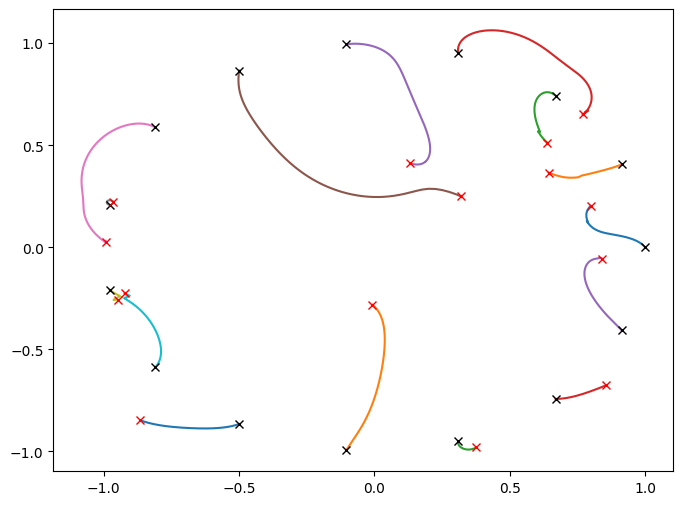

In [13]:
L1 = Alg_1(1e-2, p_ini, pl_ini, p_final,1e-8,1e-2)

#visualizar_caminos(L1,0)
visualizar_caminos(L1,1) 
print("Roots: ", L1[1][-1])
print("Error: ",np.max(np.abs(Vieta(L1[1][-1])-p_final)))
print("Steps: ", L1[2])

Error cometido:  1.9815857057579234e-09
Roots:  [ 0.79890122+0.20302362j  0.64317757+0.36636572j  0.63839668+0.51317675j
  0.7689366 +0.65223481j  0.13137352+0.41134793j  0.31971449+0.24947436j
 -0.99350926+0.02500142j -0.9642808 +0.22207381j -0.94611923-0.25832864j
 -0.92329821-0.22572955j -0.8642902 -0.84794431j -0.00803311-0.28101743j
  0.37578028-0.98001637j  0.85458011-0.67679186j  0.84144041-0.05521399j]
Error:  1.9815857057579234e-09
Steps:  1254


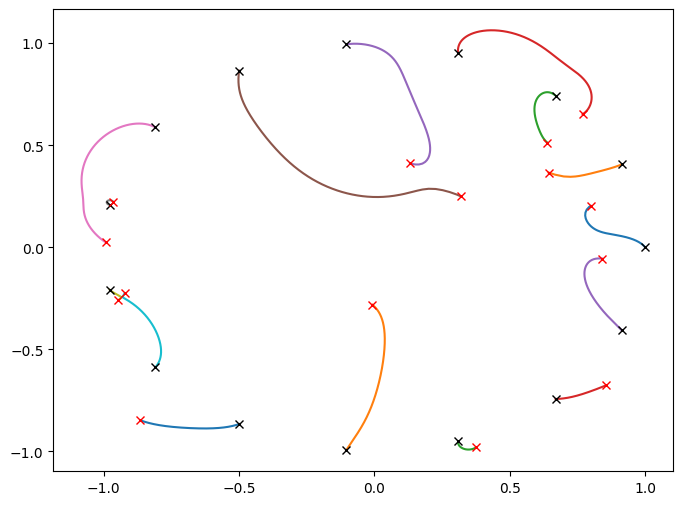

In [14]:
L=Alg_2(1e-2, p_ini, p_final,1e-6,0.0001)
L2L= np.array(levantamiento(L[0],pl_ini,1e-6))
L2=[L[0],L2L,L[1]]
#visualizar_caminos(L2,0)
visualizar_caminos(L2,1) 
print("Error cometido: ",np.max(np.abs(Vieta(L2[1][-1])-p_final)))
print("Roots: ", L2[1][-1])
print("Error: ",np.max(np.abs(Vieta(L2[1][-1])-p_final)))
print("Steps: ", L2[2])

Solution found
Roots:  [ 0.79890145+0.20302346j  0.64317664+0.36636703j  0.63839717+0.51317607j
  0.76893657+0.65223484j  0.1313734 +0.41134806j  0.31971496+0.24947379j
 -0.99350927+0.02500142j -0.9642808 +0.22207381j -0.94611924-0.25832865j
 -0.92329819-0.22572953j -0.8642902 -0.84794431j -0.00803313-0.28101744j
  0.37578028-0.98001637j  0.85458011-0.67679186j  0.84144033-0.05521404j]
Error:  5.083749871021961e-07
Steps:  25


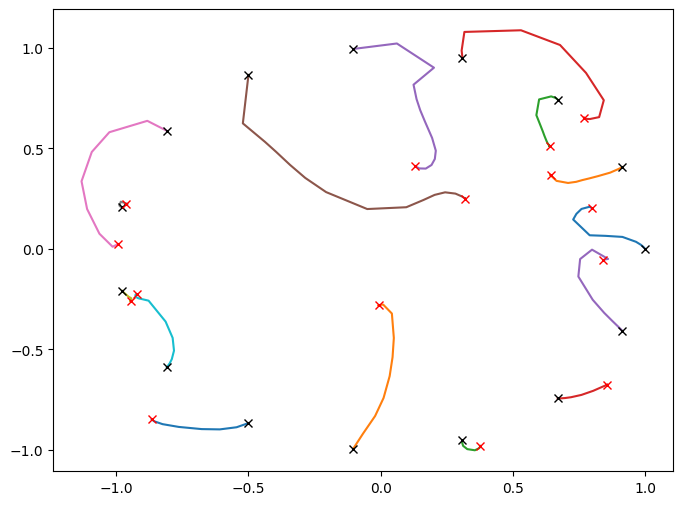

In [15]:
L3 = Alg_3(1e-2, p_ini, pl_ini, p_final, 1e-6, 1e-16,1e-1)

#visualizar_caminos(L3,0)
visualizar_caminos(L3,1) 
print("Roots: ", L3[1][-1])
print("Error: ",np.max(np.abs(Vieta(L3[1][-1])-p_final)))
print("Steps: ", L3[2])

### Pathological case

In [16]:
p_iniS = np.zeros(10, dtype=np.complex128)
p_iniS[-1] = -1
lp_iniS = gen_ini(10)
p_finS = np.zeros(10, dtype=np.complex128)
p_finS[-1] = 1

Roots:  [-9.51056590e-01-0.30901702j -5.87785298e-01-0.80901706j
  2.72004641e-15-1.00000008j  5.87785298e-01-0.80901706j
  9.51056590e-01-0.30901702j  9.51056590e-01+0.30901702j
  5.87785298e-01+0.80901706j  4.44089210e-16+1.00000008j
 -5.87785298e-01+0.80901706j -9.51056590e-01+0.30901702j]
Error:  7.76215339781672e-07
Steps:  20000


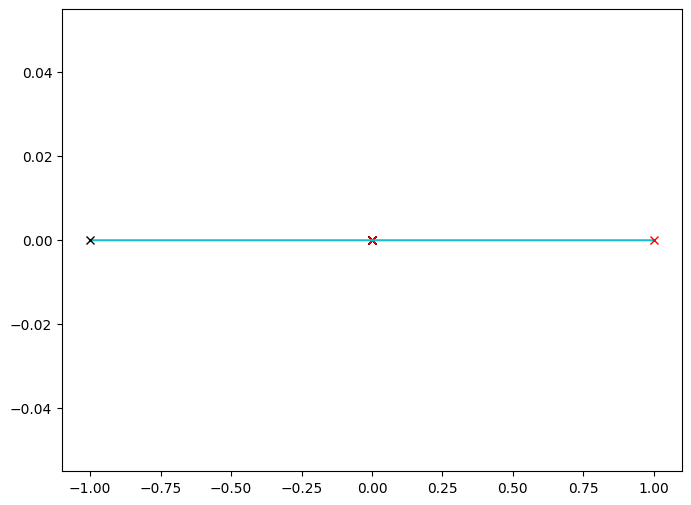

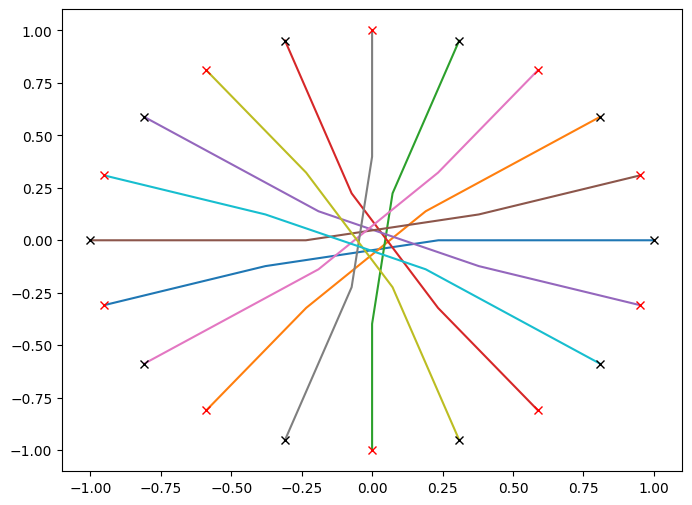

In [17]:
#PVPC algorithm
LS1 = Alg_1(1e-4, p_iniS, lp_iniS, p_finS,1e-6,1e-1)
visualizar_caminos(LS1,0) 
visualizar_caminos(LS1,1) 

print("Roots: ", LS1[1][-1])
print("Error: ",np.max(np.abs(Vieta(LS1[1][-1])-p_finS)))
print("Steps: ", LS1[2])



Raíces:  [ 9.51056516e-01-0.30901699j  9.51056516e-01+0.30901699j
  5.87785252e-01+0.80901699j  1.84019466e-13+1.j
 -5.87785252e-01+0.80901699j -9.51056516e-01+0.30901699j
 -9.51056516e-01-0.30901699j -5.87785252e-01-0.80901699j
 -1.84074977e-13-1.j          5.87785252e-01-0.80901699j]
Error cometido:  1.272952893612442e-10
Steps:  401


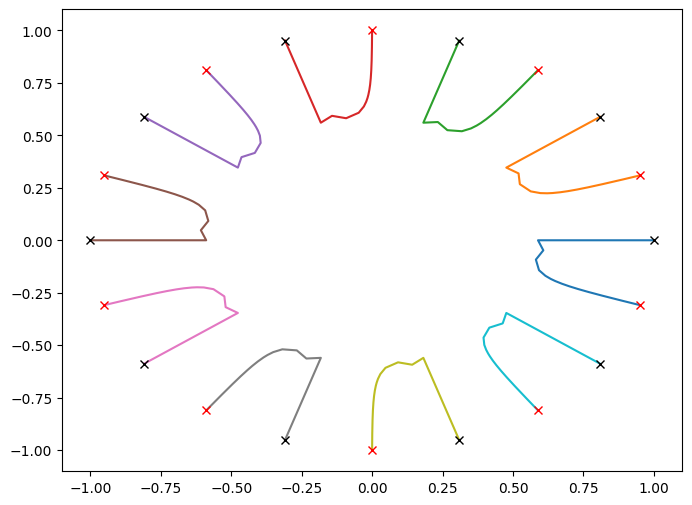

In [18]:
# DVPC algorithm

LS2=Alg_2(5e-3, p_iniS, p_finS,1e-6,1e-3)
LSing2= np.array(levantamiento(LS2[0],lp_iniS,1e-6))
LSingC=np.array([LS2[0],LSing2])

#visualizar_caminos(LSingC,0) 
visualizar_caminos(LSingC,1) 

print("Raíces: ", LSingC[1][-1])
print("Error cometido: ",np.max(np.abs(Vieta(LSingC[1][-1])-p_finS)))
print("Steps: ", LS2[1])

Solution found
Roots:  [ 9.51056489e-01-0.30901698j  9.51056489e-01+0.30901699j
  5.87785235e-01+0.80901697j -1.16296109e-09+0.99999997j
 -5.87785238e-01+0.80901697j -9.51056492e-01+0.30901699j
 -9.51056492e-01-0.30901698j -5.87785238e-01-0.80901697j
 -1.80606029e-09-0.99999997j  5.87785235e-01-0.80901697j]
Error:  2.7130827340293706e-07
Steps:  2279


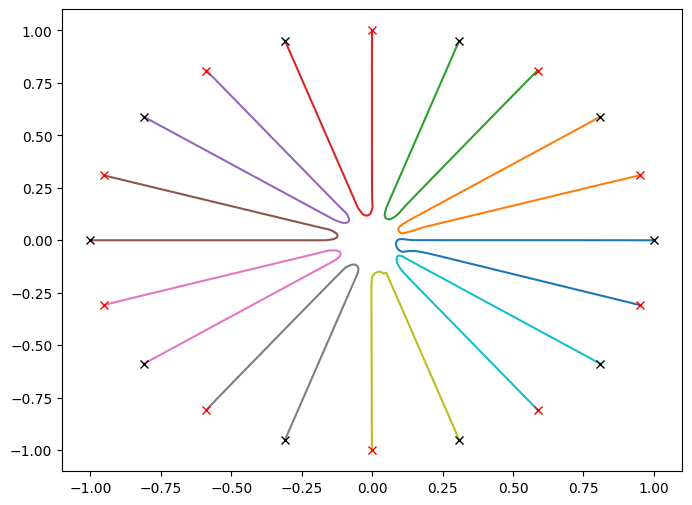

In [19]:
#LGPC algorithm


LS3 = Alg_3(1e-2, p_iniS, lp_iniS, p_finS, 1e-6, 1e-16,1e-1)

#visualizar_caminos(LS3,0)
visualizar_caminos(LS3,1) 
print("Roots: ", LS3[1][-1])
print("Error: ",np.max(np.abs(Vieta(LS3[1][-1])-p_finS)))
print("Steps: ", LS3[2])


## Example Homotopy TFM

In [20]:
def t_discret(n):
    return(np.array([i/n for i in range (0,n+1)],dtype=np.complex128))


# If a is associated with the polynomial g(x) and b with f(x), this function constructs a discretization of the path induced by the normalized homotopy (when it exists)
# H(x, t) = t f(x) + gamma(1 - t) g(x) between a and b.

def camino_gamma(a,b,n,gamma):
    t=t_discret(n)
    camino=np.zeros((n+1,len(a)), dtype=np.complex128)
    for i in range (n+1):
        camino[i]=(t[i]*b+(1-t[i])*gamma*a)/(t[i]+gamma*(1-t[i]))
    return(camino)


In [21]:
p_iniH = np.array([0,0,0,-1], dtype=np.complex128)
lp_iniH = gen_ini(4)
p_intH=Vieta(np.array([1/9+1j/3, 1/9+1j/3, 1j/4-3j/4, 1j/4-3j/4], dtype=np.complex128))
p_finH=np.array([-0.44444444+0.66666667j , 0.63580247-0.2962963j , -0.03703704+0.13580247j ,1.04938272-0.03703704j], dtype=np.complex128)


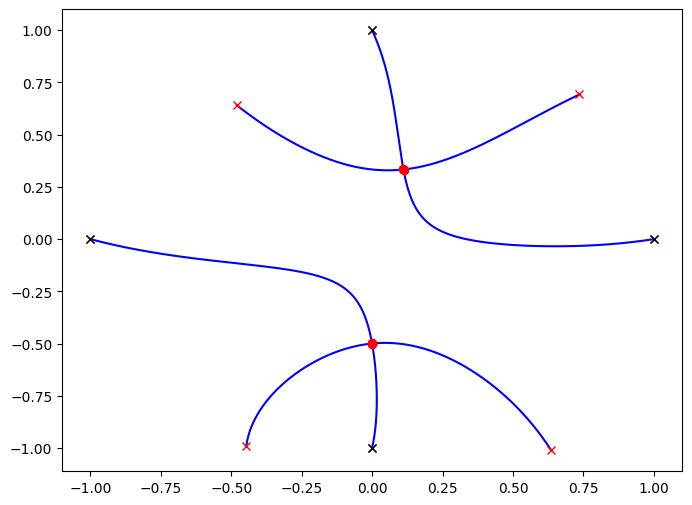

In [22]:
# Path collapse.

nG=99999
caminoG=camino_gamma(p_iniH,p_finH,nG,1)
LeGamma=levantamiento (caminoG,lp_iniH, 1e-6)
CaminoYLGamma=np.array([caminoG,LeGamma], dtype=np.complex128)


visualizar_H(CaminoYLGamma,1)
plt.plot(CaminoYLGamma[1][nG//2][0].real, CaminoYLGamma[1][nG//2][0].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][1].real, CaminoYLGamma[1][nG//2][1].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][2].real, CaminoYLGamma[1][nG//2][2].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][3].real, CaminoYLGamma[1][nG//2][3].imag,color="red", marker="o")



#Puntos iniciales
plt.plot(lp_iniH[0].real, lp_iniH[0].imag,color="black", marker="x")
plt.plot(lp_iniH[1].real, lp_iniH[1].imag,color="black", marker="x")
plt.plot(lp_iniH[2].real, lp_iniH[2].imag,color="black", marker="x")
plt.plot(lp_iniH[3].real, lp_iniH[3].imag,color="black", marker="x")

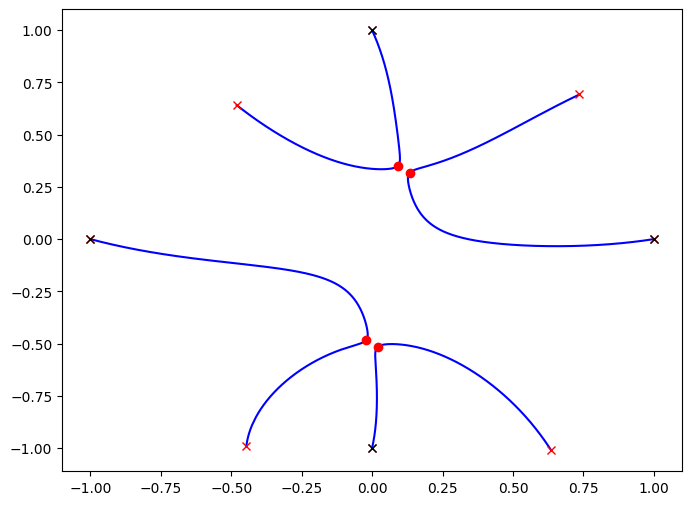

In [23]:
# Gamma= 1+0.001j
caminoG=camino_gamma(p_iniH,p_finH,nG,1+0.001j)
LeGamma=levantamiento (caminoG,lp_iniH, 1e-6)
CaminoYLGamma=np.array([caminoG,LeGamma], dtype=np.complex128)


visualizar_H(CaminoYLGamma,1)
plt.plot(CaminoYLGamma[1][nG//2][1].real, CaminoYLGamma[1][nG//2][1].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][0].real, CaminoYLGamma[1][nG//2][0].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][2].real, CaminoYLGamma[1][nG//2][2].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][3].real, CaminoYLGamma[1][nG//2][3].imag,color="red", marker="o")

plt.plot(lp_iniH[0].real, lp_iniH[0].imag,color="black", marker="x")
plt.plot(lp_iniH[1].real, lp_iniH[1].imag,color="black", marker="x")
plt.plot(lp_iniH[2].real, lp_iniH[2].imag,color="black", marker="x")
plt.plot(lp_iniH[3].real, lp_iniH[3].imag,color="black", marker="x")



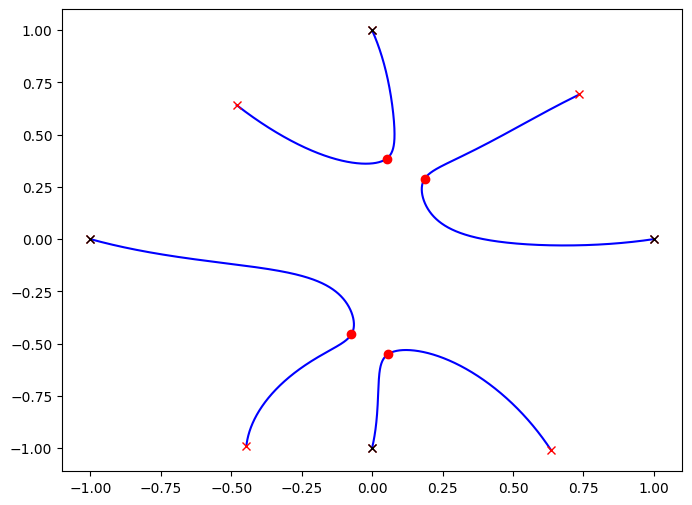

In [24]:
# Gamma= 1+0.01j

caminoG=camino_gamma(p_iniH,p_finH,nG,1+0.01j)
LeGamma=levantamiento (caminoG,lp_iniH, 1e-6)
CaminoYLGamma=np.array([caminoG,LeGamma], dtype=np.complex128)


visualizar_H(CaminoYLGamma,1)
plt.plot(CaminoYLGamma[1][nG//2][1].real, CaminoYLGamma[1][nG//2][1].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][0].real, CaminoYLGamma[1][nG//2][0].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][2].real, CaminoYLGamma[1][nG//2][2].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][3].real, CaminoYLGamma[1][nG//2][3].imag,color="red", marker="o")

plt.plot(lp_iniH[0].real, lp_iniH[0].imag,color="black", marker="x")
plt.plot(lp_iniH[1].real, lp_iniH[1].imag,color="black", marker="x")
plt.plot(lp_iniH[2].real, lp_iniH[2].imag,color="black", marker="x")
plt.plot(lp_iniH[3].real, lp_iniH[3].imag,color="black", marker="x")



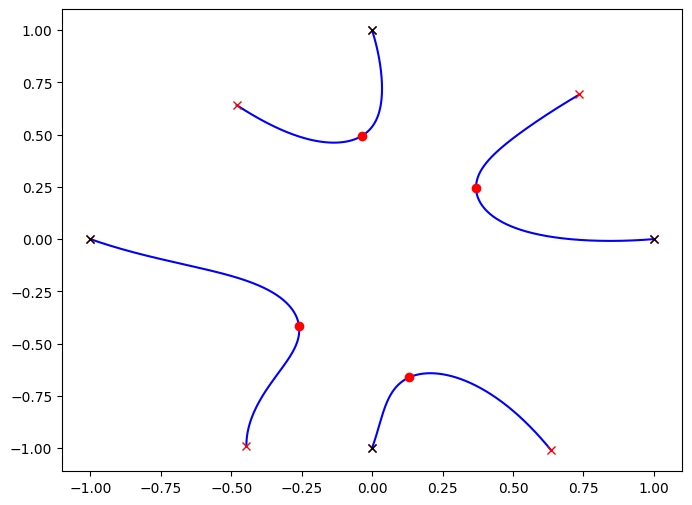

In [25]:
# Gamma=1+0.1j
caminoG=camino_gamma(p_iniH,p_finH,nG,1+0.1j)
LeGamma=levantamiento (caminoG,lp_iniH, 1e-6)
CaminoYLGamma=np.array([caminoG,LeGamma], dtype=np.complex128)


visualizar_H(CaminoYLGamma,1)
plt.plot(CaminoYLGamma[1][nG//2][0].real, CaminoYLGamma[1][nG//2][0].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][1].real, CaminoYLGamma[1][nG//2][1].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][2].real, CaminoYLGamma[1][nG//2][2].imag,color="red", marker="o")
plt.plot(CaminoYLGamma[1][nG//2][3].real, CaminoYLGamma[1][nG//2][3].imag,color="red", marker="o")

plt.plot(lp_iniH[0].real, lp_iniH[0].imag,color="black", marker="x")
plt.plot(lp_iniH[1].real, lp_iniH[1].imag,color="black", marker="x")
plt.plot(lp_iniH[2].real, lp_iniH[2].imag,color="black", marker="x")
plt.plot(lp_iniH[3].real, lp_iniH[3].imag,color="black", marker="x")

### Solving with Alg_1, Alg_2, Alg_3.

Roots:  [ 0.73566694+0.69253732j -0.48055117+0.6416661j  -0.44604909-0.98960457j
  0.63537776-1.01126553j]
Error:  1.4233436332612911e-11
Steps:  244


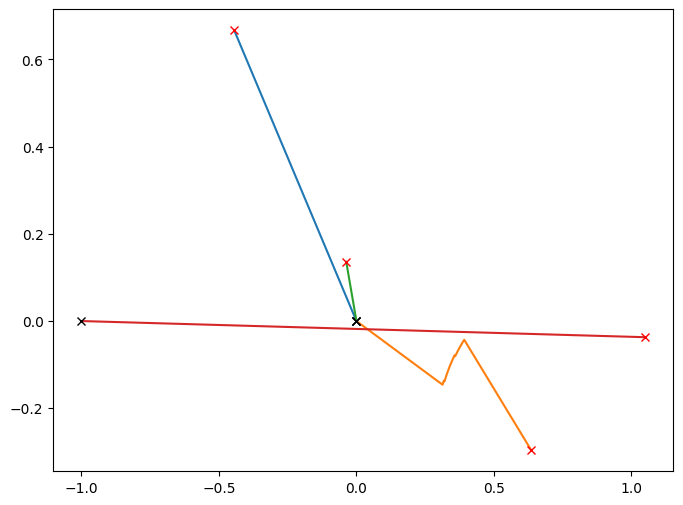

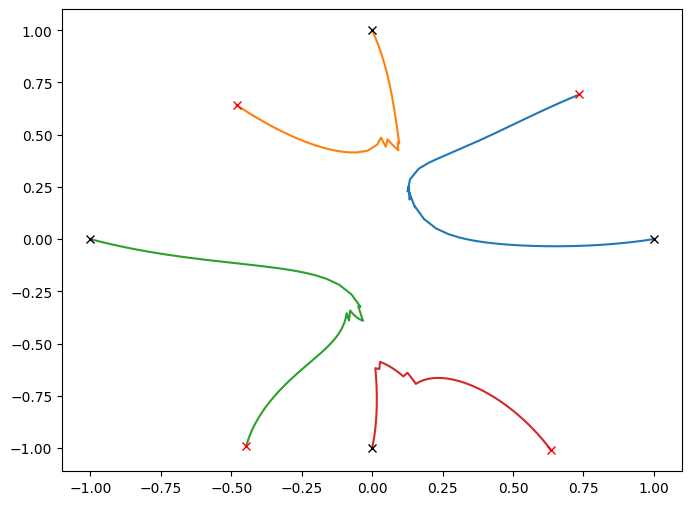

In [26]:
LH1 = Alg_1(1e-2, p_iniH, lp_iniH, p_finH,1e-7,2e-1)
visualizar_caminos(LH1,0) 
visualizar_caminos(LH1,1) 


print("Roots: ", LH1[1][-1])
print("Error: ",np.max(np.abs(Vieta(LH1[1][-1])-p_finH)))
print("Steps: ", LH1[2])

Roots:  [ 0.73566695+0.69253733j -0.48055118+0.64166611j -0.44604911-0.98960458j
  0.63537778-1.01126553j]
Error:  4.555007610368834e-08
Steps:  58


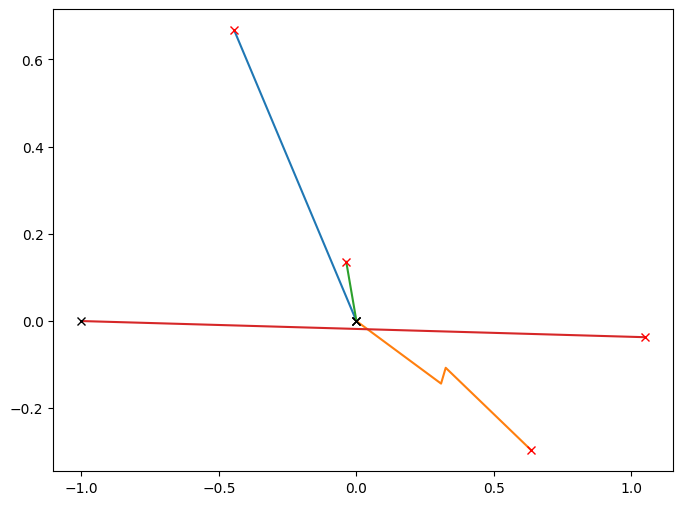

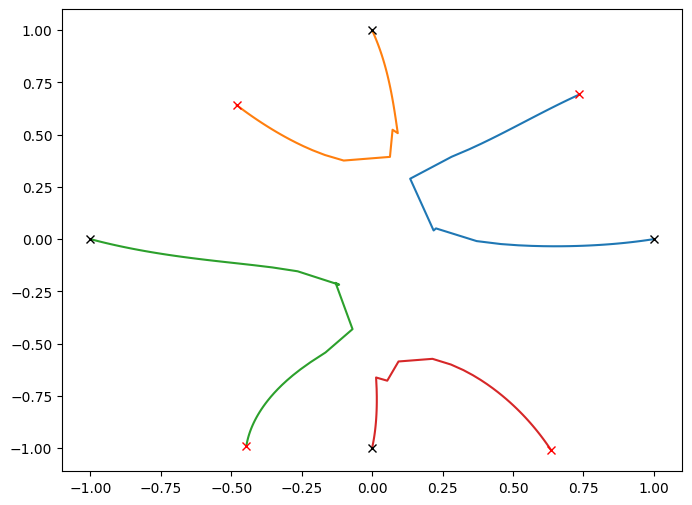

In [27]:
LS2=Alg_2(4e-2, p_iniH, p_finH,1e-7,3e-1)
LSing2= np.array(levantamiento(LS2[0],lp_iniH,1e-6))
LSingC=np.array([LS2[0],LSing2])

visualizar_caminos(LSingC,0) 
visualizar_caminos(LSingC,1) 

print("Roots: ", LSingC[1][-1])
print("Error: ",np.max(np.abs(Vieta(LSingC[1][-1])-p_finH)))
print("Steps: ", LS2[1])

Solution found
Roots:  [-0.48055117+0.6416661j   0.73566694+0.69253733j  0.63537776-1.01126553j
 -0.44604909-0.98960457j]
Error:  1.1362064561394993e-08
Steps:  19


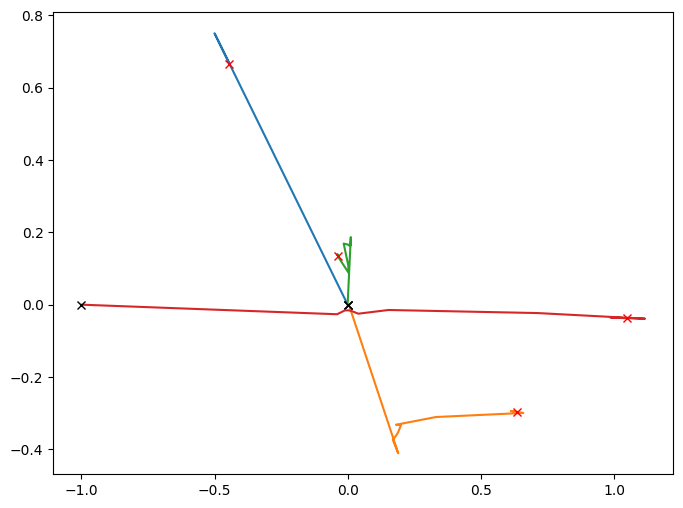

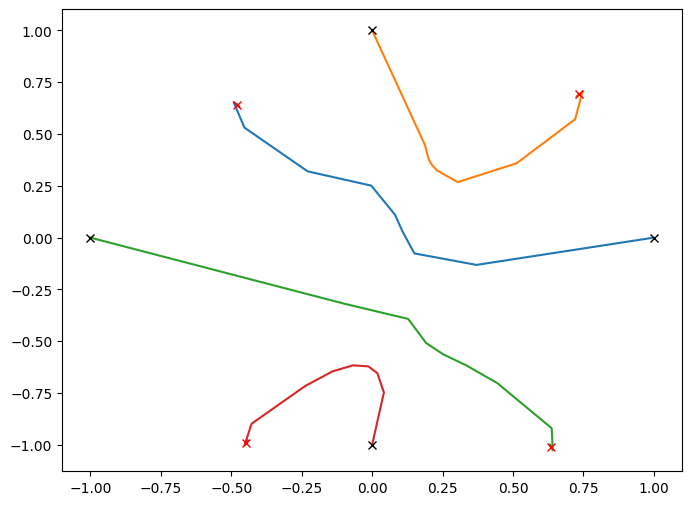

In [28]:
LH3 = Alg_3(1e-2, p_iniH, lp_iniH, p_finH, 1e-7, 1e-16,1e-1)
visualizar_caminos(LH3,0) 
visualizar_caminos(LH3,1) 
print("Roots: ", LH3[1][-1])

#Error:
print("Error: ",np.max(np.abs(Vieta(LH3[1][-1])-p_finH)))
print("Steps: ", LH3[2])



## Performance measurements

In [34]:
import time

def rend_camino1(dist,pl_iniT,p_iniT,p_finalTV,tol,epsilon):
    tiempos = []
    errores = []
    pasos=[]
    i=0
    l=len(p_iniT)
    

    for p_finalT in p_finalTV:
        #print(i, " N: ",l, " Alg_1")
        i=i+1
        inicio = time.perf_counter()
        comp1 = Alg_1(dist, p_iniT, pl_iniT, p_finalT,tol,epsilon)
        fin = time.perf_counter() 
        tiempo = fin - inicio
        tiempos.append(tiempo)
        error = np.max(np.abs(Vieta(comp1[1][-1]) - p_finalT))
        errores.append(error)
        pasos.append(comp1[2])

    Tmedio = np.mean(tiempos)
    Emedio = np.mean(errores)
    Pmedio=np.mean(pasos)
    
    return Tmedio, Emedio,Pmedio



def rend_camino2(dist,pl_iniT,p_iniT,p_finalTV,tol, epsilon2):
    tiempos=[]
    errores=[]
    pasos=[]
    
    i=0
    l=len(p_iniT)


    for p_finalT in p_finalTV:
        #print(i, " N: ",l, " Alg_2")
        #print(i)
        i=i+1

        inicio = time.perf_counter()
        comp2 = Alg_2(dist, p_iniT, p_finalT, tol,epsilon2)
        comp2L= np.array(levantamiento(comp2[0],pl_iniT,1e-6))

        L2Comp2=np.array([comp2[0],comp2L])
        
        fin = time.perf_counter() 
        tiempo = fin - inicio
        tiempos.append(tiempo)
        error = np.max(np.abs(Vieta(L2Comp2[1][-1]) - p_finalT))
        errores.append(error)
        pasos.append(comp2[1])

    Tmedio = np.mean(tiempos)
    Emedio = np.mean(errores)
    Pmedio=np.mean(pasos)
    
    return Tmedio, Emedio,Pmedio



def rend_camino3v2(dist,pl_iniT,p_iniT,p_finalTV,tol,av_min, dist_seg):
    tiempos=[]
    errores=[]
    pasos=[]
    i=0
    l=len(p_iniT)

    for p_finalT in p_finalTV:
        #print(i, " N: ",l, " Alg_3")
        i=i+1
        inicio= time.perf_counter()
        comp3v2= Alg_3(dist, p_iniT, pl_iniT, p_finalT, tol, av_min, dist_seg)
        fin= time.perf_counter() 
        tiempo= fin-inicio
        tiempos.append(tiempo)
        error= np.max(np.abs(Vieta(comp3v2[1][-1])-p_finalT))
        errores.append(error)
        pasos.append(comp3v2[2])

    Tmedio=np.mean(tiempos)
    Emedio=np.mean(errores)
    Pmedio=np.mean(pasos)
    #print("Pmedio:",Pmedio)
    
    
    return Tmedio, Emedio, Pmedio    

In [35]:
np.random.seed(2024)
dist = 1e-2
tol = 1e-7
av_min=1e-16

dist_seg=1e-2
epsilon=1e-2
epsilon2=0.01

def tiempos_ej123(dist,tol,av_min, dist_seg,N_max,repeticiones=100):

    tiemposE1=[]
    erroresE1=[]
    pasosE1=[]

    tiemposE2=[]
    erroresE2=[]
    pasosE2=[]
    
    tiemposE3=[]
    erroresE3=[]
    pasosE3=[]

    for n in range (2,N_max):
        
        pl_iniT=gen_ini(n)
        p_iniT=Vieta(pl_iniT)
        p_finalTV=np.array([Vieta(gen_polinomio(n,-1,1,-1,1)) for i in range(0,repeticiones)])
        

        Tmedio, Emedio,Pmedio = rend_camino1(dist, pl_iniT,p_iniT,p_finalTV, tol,epsilon)
        tiemposE1.append(Tmedio)
        erroresE1.append(Emedio)
        pasosE1.append(Pmedio)

        Tmedio, Emedio,Pmedio = rend_camino2(dist,pl_iniT,p_iniT,p_finalTV, tol,epsilon2)
        tiemposE2.append(Tmedio)
        erroresE2.append(Emedio)
        pasosE2.append(Pmedio)
        
        Tmedio, Emedio,Pmedio = rend_camino3v2(1e-2,pl_iniT,p_iniT,p_finalTV, tol,av_min,dist_seg)
        tiemposE3.append(Tmedio)
        erroresE3.append(Emedio)
        pasosE3.append(Pmedio)

    tiempos=[tiemposE1,tiemposE2,tiemposE3]
    errores=[erroresE1,erroresE2,erroresE3]
    pasos=[pasosE1,pasosE2,pasosE3]
    return tiempos, errores, pasos
    
Res123=tiempos_ej123(dist,tol,av_min, dist_seg,21,25)

        

In [36]:
np.random.seed(2024)
dist = 1e-2
tol = 1e-7
av_min=1e-16

dist_seg=1e-2
epsilon=1e-2
epsilon2=0.01

def tiempos_ej23(dist,tol,av_min, dist_seg,N_max,repeticiones=100):

  

    tiemposE2=[]
    erroresE2=[]
    pasosE2=[]
    
    tiemposE3=[]
    erroresE3=[]
    pasosE3=[]

    for n in range (2,N_max):
        
        pl_iniT=gen_ini(n)
        p_iniT=Vieta(pl_iniT)
        p_finalTV=np.array([Vieta(gen_polinomio(n,-1,1,-1,1)) for i in range(0,repeticiones)])
        

 

        Tmedio, Emedio,Pmedio = rend_camino2(dist,pl_iniT,p_iniT,p_finalTV, tol,epsilon2)
        tiemposE2.append(Tmedio)
        erroresE2.append(Emedio)
        pasosE2.append(Pmedio)
        
        Tmedio, Emedio,Pmedio = rend_camino3v2(1e-2,pl_iniT,p_iniT,p_finalTV, tol,av_min,dist_seg)
        tiemposE3.append(Tmedio)
        erroresE3.append(Emedio)
        pasosE3.append(Pmedio)

    tiempos=[tiemposE2,tiemposE3]
    errores=[erroresE2,erroresE3]
    pasos=[pasosE2,pasosE3]
    return tiempos, errores, pasos
    
Res23=tiempos_ej23(dist,tol,av_min, dist_seg,25,1)

        

In [37]:
np.random.seed(2024)
dist = 1e-2
tol = 1e-7
av_min=1e-16

dist_seg=1e-2
epsilon=1e-2
epsilon2=0.01

def tiempos_ej(dist,tol,av_min, dist_seg,N_max,repeticiones=100):
    
    tiemposE3=[]
    erroresE3=[]
    pasosE3=[]

    for n in range (2,N_max):
        
        pl_iniT=gen_ini(n)
        p_iniT=Vieta(pl_iniT)
        p_finalTV=np.array([Vieta(gen_polinomio(n,-1,1,-1,1)) for i in range(0,repeticiones)])

        
        Tmedio, Emedio,Pmedio = rend_camino3v2(1e-2,pl_iniT,p_iniT,p_finalTV, tol,av_min,dist_seg)
        tiemposE3.append(Tmedio)
        erroresE3.append(Emedio)
        pasosE3.append(Pmedio)

    tiempos=[tiemposE3]
    errores=[erroresE3]
    pasos=[pasosE3]
    return tiempos, errores, pasos
    
Res=tiempos_ej(dist,tol,av_min, dist_seg,40,50)

        

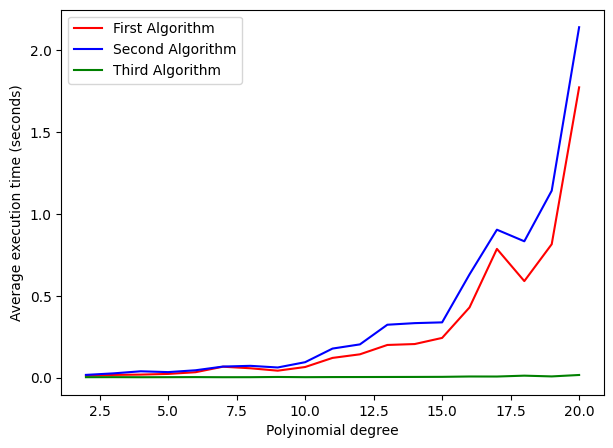

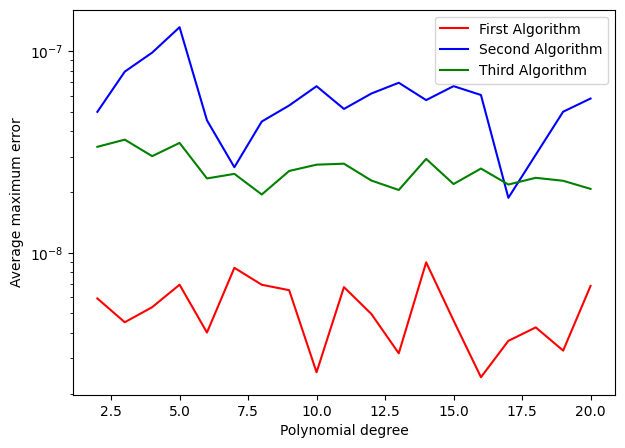

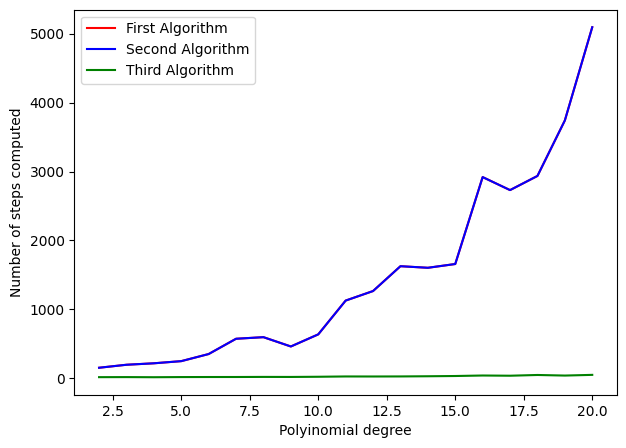

In [38]:
import matplotlib.pyplot as plt

tiempos= Res123[0]
errores=Res123[1]
pasos=Res123[2]

tiemposE1=tiempos[0]
tiemposE2=tiempos[1]
tiemposE3=tiempos[2]

erroresE1=errores[0]
erroresE2=errores[1]
erroresE3=errores[2]

pasosE1=pasos[0]
pasosE2=pasos[1]
pasosE3=pasos[2]


N=list(range(2,2+len(tiemposE1)))

plt.figure(figsize=(7, 5))

plt.plot(N,tiemposE1, label="First Algorithm", color="red")
plt.plot(N,tiemposE2, label="Second Algorithm", color="blue")
plt.plot(N,tiemposE3, label="Third Algorithm", color="green")

plt.xlabel("Polyinomial degree")
plt.ylabel("Average execution time (seconds)")
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))


plt.plot(N,erroresE1, label="First Algorithm", color="red")
plt.plot(N,erroresE2, label="Second Algorithm", color="blue")
plt.plot(N,erroresE3, label="Third Algorithm", color="green")

plt.xlabel("Polynomial degree")
plt.ylabel("Average maximum error")
plt.yscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))

plt.plot(N,pasosE1, label="First Algorithm", color="red")
plt.plot(N,pasosE2, label="Second Algorithm", color="blue")
plt.plot(N,pasosE3, label="Third Algorithm", color="green")

plt.xlabel("Polyinomial degree")
plt.ylabel("Number of steps computed")
plt.legend()
plt.show()
 

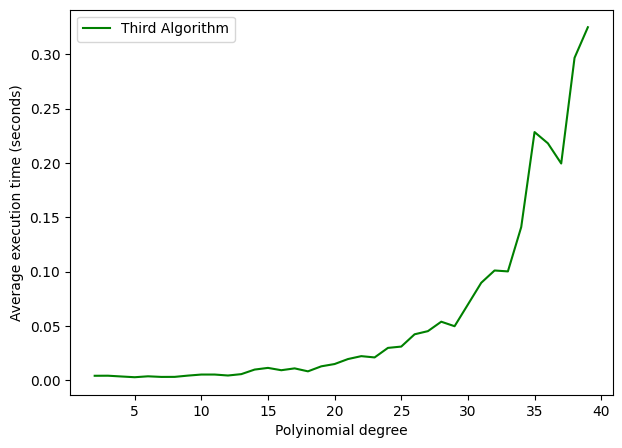

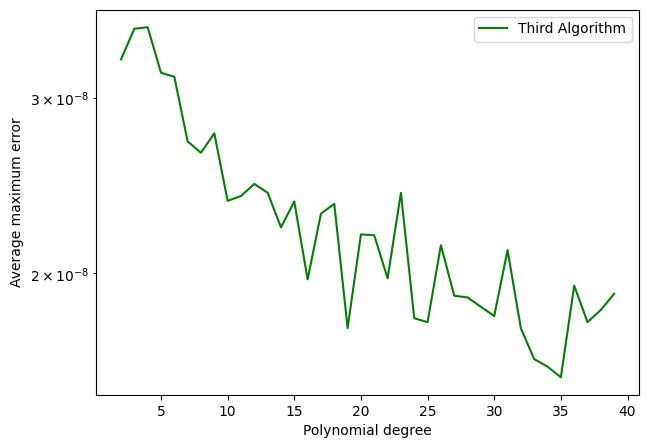

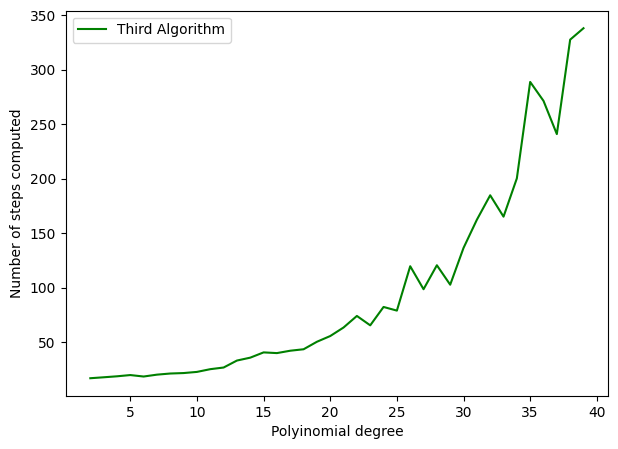

In [39]:
import matplotlib.pyplot as plt

tiempos= Res[0]
errores=Res[1]
pasos=Res[2]

tiemposE3=tiempos[0]
erroresE3=errores[0]
pasosE3=pasos[0]


N=list(range(2,2+len(tiemposE3)))

plt.figure(figsize=(7, 5))

plt.plot(N,tiemposE3, label="Third Algorithm", color="green")

plt.xlabel("Polyinomial degree")
plt.ylabel("Average execution time (seconds)")
plt.legend()
plt.show()


plt.figure(figsize=(7, 5))

plt.plot(N,erroresE3, label="Third Algorithm", color="green")

plt.xlabel("Polynomial degree")
plt.ylabel("Average maximum error")
plt.yscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))

plt.plot(N,pasosE3, label="Third Algorithm", color="green")

plt.xlabel("Polyinomial degree")
plt.ylabel("Number of steps computed")
plt.legend()
plt.show()
 